In [162]:
from pathlib import Path
import pandas as pd

In [163]:
training = pd.read_csv('/Users/admin/dev/algobetting/analysis/marathon_overtraining/i451607_activities-2.csv')

In [164]:
# Combine all Garmin sleep export CSVs (overlapping 28-day windows) into one df
sleep_files = sorted(Path('.').glob('Sleep-*.csv'))

dfs = []
for f in sleep_files:
    df = pd.read_csv(f, encoding='utf-8-sig')
    df = df.rename(columns={'Sleep Score 4 Weeks': 'date'})
    dfs.append(df)

sleep_df = pd.concat(dfs, ignore_index=True)
sleep_df['date'] = pd.to_datetime(sleep_df['date'], errors='coerce')

# drop rows with no real data (Garmin fills missing days with all '--')
sleep_df = sleep_df.dropna(subset=['date'])
sleep_df = sleep_df[sleep_df['Score'] != '--']

# exports overlap, so de-dupe on date
sleep_df = sleep_df.drop_duplicates(subset='date', keep='first')
sleep_df = sleep_df.sort_values('date').reset_index(drop=True)

sleep_df.shape

(250, 14)

In [165]:
sleep_df.head()

,date,Score,Resting Heart Rate,Body Battery,Pulse Ox,Respiration,Skin Temp Change,HRV Status,Quality,Duration,Sleep Need,Bedtime,Wake Time,Sleep Alignment
0,2025-12-14,83,54,63,--,12.57,0°,33,Good,7h 27min,9h 0min,11:08 PM,6:40 AM,--
1,2025-12-15,85,52,54,--,12.21,'+0.2°,33,Good,7h 58min,8h 50min,9:32 PM,5:30 AM,--
2,2025-12-16,86,48,61,--,10.95,'-0.2°,33,Good,8h 11min,8h 0min,9:13 PM,5:31 AM,--
3,2025-12-17,83,53,45,--,12.03,'-0.4°,34,Good,8h 2min,8h 0min,10:05 PM,6:15 AM,--
4,2025-12-18,89,49,48,--,11.45,'-0.4°,33,Good,8h 14min,8h 0min,9:06 PM,5:26 AM,--


In [166]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import numpy as np

# Fonts (same system as postmortem_v2.ipynb / viz/pl_scatter.py)
for _path in ['/Users/admin/Library/Fonts/Roboto-Regular.ttf',
              '/Users/admin/Library/Fonts/Roboto-Bold.ttf']:
    try:
        fm.fontManager.addfont(_path)
    except Exception:
        pass

# Shared palette - datawrapper-style house colours (postmortem_v2.ipynb / value_analysis.ipynb)
C_XG    = '#2a78d6'
C_GOALS = '#eb6834'
C_PRED  = '#1baf7a'
C_OVER  = '#e34948'
C_UNDER = '#2a78d6'
C_GRID  = '#eeeeee'
C_AXIS  = '#cccccc'
C_MUTED = '#888888'
C_INK   = '#1a1a1a'
C_INK2  = '#666666'

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'Roboto',
    'axes.edgecolor': C_AXIS,
    'axes.labelcolor': C_INK2,
    'text.color': C_INK,
    'xtick.color': C_INK2,
    'ytick.color': C_INK2,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'axes.grid': True,
    'grid.color': C_GRID,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})


def _dw_style(ax, grid_axis='both'):
    """Datawrapper-style axis dressing: hide top/right spines, faint grid,
    no tick marks, muted tick labels - matches viz/pl_scatter.py."""
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(C_AXIS)
    ax.spines['bottom'].set_color(C_AXIS)
    ax.tick_params(length=0, colors=C_INK2)
    ax.grid(axis=grid_axis, color=C_GRID, linewidth=0.8)
    ax.set_axisbelow(True)


def _dw_title(ax, title, subtitle=None, y=1.12, dy=0.055, size=13, sub_size=9.5):
    """Left-aligned bold title + grey subtitle sitting above the axes,
    matching the title block in viz/pl_scatter.py / pl_gw_predictions_viz.py."""
    ax.text(0, y, title, transform=ax.transAxes,
            fontsize=size, fontweight='bold', color=C_INK, va='bottom', ha='left')
    if subtitle:
        ax.text(0, y - dy, subtitle, transform=ax.transAxes,
                fontsize=sub_size, color=C_MUTED, va='bottom', ha='left')

In [167]:
# Aggregate activities to one row per calendar day.
# icu_fatigue/icu_fitness are running ATL/CTL as-of that activity, so take the
# last activity of the day for the day's end-of-day value; everything else sums.
act = training.copy()
act["date"] = pd.to_datetime(act["start_date_local"]).dt.floor("D")
act = act.sort_values("start_date_local")

daily = act.groupby("date").agg(
    training_load=("icu_training_load", "sum"),
    n_sessions=("id", "count"),
    moving_time_min=("moving_time", lambda s: s.sum() / 60),
    distance_km=("distance", lambda s: s.sum() / 1000),
    avg_hr=("average_heartrate", "mean"),
    avg_rpe=("icu_rpe", "mean"),
    atl=("icu_fatigue", "last"),
    ctl=("icu_fitness", "last"),
).reset_index()

daily["form"] = daily["ctl"] - daily["atl"]  # TSB-style: negative = accumulating fatigue

daily.tail()

,date,training_load,n_sessions,moving_time_min,distance_km,avg_hr,avg_rpe,atl,ctl,form
282,2026-08-19,57,2,64.400000,10.72907,124.0,2.0,60.549385,57.41696,-3.132425
283,2026-08-20,51,1,48.166667,8.73401,135.0,4.0,59.278152,57.26598,-2.012172
284,2026-08-21,41,2,70.900000,21.23618,108.0,2.0,56.844925,56.88327,0.038345
285,2026-08-22,120,2,136.066667,31.04985,123.5,5.0,65.252260,58.36830,-6.883960
286,2026-08-23,50,1,58.900000,9.71596,127.0,2.0,63.221848,58.17141,-5.050438


In [168]:
# Full daily calendar over the sleep-tracked period, training days filled with 0,
# ATL/CTL forward-filled through rest days (they don't reset, they decay).
cal = pd.DataFrame({"date": pd.date_range(sleep_df["date"].min(), sleep_df["date"].max(), freq="D")})
cal = cal.merge(daily, on="date", how="left")
for c in ["training_load", "n_sessions", "moving_time_min", "distance_km"]:
    cal[c] = cal[c].fillna(0)
cal[["atl", "ctl"]] = cal[["atl", "ctl"]].ffill()
cal["form"] = cal["ctl"] - cal["atl"]
cal["load_7d"] = cal["training_load"].rolling(7, min_periods=1).sum()

# Garmin labels a sleep row by the WAKE date (bedtime is the evening before), so
# training done on day D is followed by the sleep dated D+1. Pair on that lag.
sleep_clean = sleep_df.copy()
for col in ["Score", "Resting Heart Rate", "Body Battery", "Respiration", "HRV Status"]:
    sleep_clean[col] = pd.to_numeric(sleep_clean[col], errors="coerce")
sleep_clean["duration_hr"] = sleep_clean["Duration"].str.extract(r"(\d+)h\s*(\d+)?").astype(float).fillna(0).apply(
    lambda r: r[0] + r[1] / 60, axis=1
)

merged = cal.merge(
    sleep_clean.rename(columns={"date": "next_date"}).assign(date=lambda d: d["next_date"] - pd.Timedelta(days=1)),
    on="date", how="left", suffixes=("", "_sleep"),
)

merged = merged.rename(columns={
    "Score": "sleep_score_next",
    "Resting Heart Rate": "rhr_next",
    "HRV Status": "hrv_next",
    "duration_hr": "sleep_hours_next",
})

merged[["date", "training_load", "load_7d", "atl", "ctl", "form", "sleep_score_next", "rhr_next", "hrv_next", "sleep_hours_next"]].tail(10)

,date,training_load,load_7d,atl,ctl,form,sleep_score_next,rhr_next,hrv_next,sleep_hours_next
242,2026-08-13,57.0,477.0,59.484352,56.600918,-2.883434,75.0,48.0,46.0,7.650000
243,2026-08-14,36.0,459.0,56.358067,56.116215,-0.241852,88.0,45.0,46.0,7.750000
244,2026-08-15,134.0,453.0,66.693924,57.948690,-8.745234,86.0,46.0,46.0,7.450000
245,2026-08-16,49.0,449.0,64.338470,57.738140,-6.600330,89.0,46.0,46.0,7.466667
246,2026-08-17,47.0,451.0,62.030340,57.485490,-4.544850,79.0,49.0,44.0,8.566667
247,2026-08-18,55.0,442.0,61.094444,57.427010,-3.667434,80.0,48.0,43.0,7.633333
248,2026-08-19,57.0,435.0,60.549385,57.416960,-3.132425,83.0,49.0,42.0,7.466667
249,2026-08-20,51.0,429.0,59.278152,57.265980,-2.012172,86.0,48.0,43.0,7.650000
250,2026-08-21,41.0,434.0,56.844925,56.883270,0.038345,87.0,48.0,42.0,7.433333
251,2026-08-22,120.0,420.0,65.252260,58.368300,-6.883960,NaN,NaN,NaN,NaN


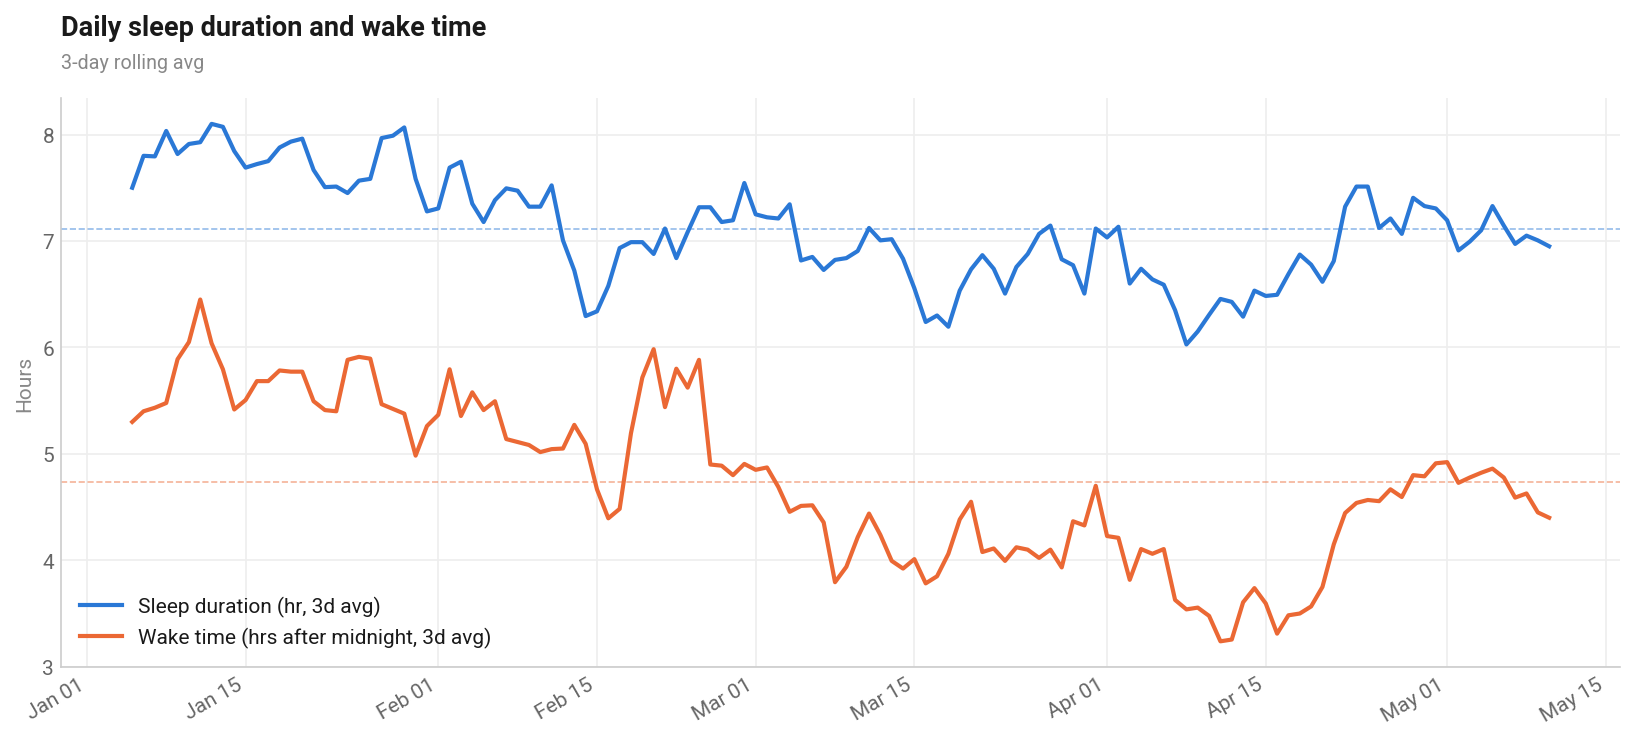

In [169]:
# Daily sleep duration and wake time, first Monday of January through May 11,
# smoothed with a 3-day rolling average. Both series are naturally denominated
# in hours (duration = hours slept, wake time = hours after midnight) and their
# ranges overlap, so one shared axis reads cleanly without rescaling either one.
# Plain, unhighlighted read of the raw signal (dashed lines = period averages,
# for reference only) - the changepoint model below determines where (if
# anywhere) to draw a highlighted window, rather than eyeballing it first and
# confirming it after.
window = sleep_clean.loc[sleep_clean["date"].between("2026-01-05", "2026-05-10"), ["date", "duration_hr", "Wake Time"]].copy()
wake_dt = pd.to_datetime(window["Wake Time"], format="%I:%M %p")
window["wake_hour"] = wake_dt.dt.hour + wake_dt.dt.minute / 60

full_days = pd.DataFrame({"date": pd.date_range("2026-01-05", "2026-05-10", freq="D")})
window = full_days.merge(window, on="date", how="left")
window["duration_smooth"] = window["duration_hr"].rolling(3, min_periods=1).mean()
window["wake_smooth"] = window["wake_hour"].rolling(3, min_periods=1).mean()

dur_mean = window["duration_smooth"].mean()
wake_mean = window["wake_smooth"].mean()

fig, ax = plt.subplots(figsize=(11, 5))

ax.axhline(dur_mean, color=C_XG, linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(wake_mean, color=C_GOALS, linewidth=0.8, linestyle="--", alpha=0.5)

ax.plot(window["date"], window["duration_smooth"], color=C_XG, linewidth=2,
        label="Sleep duration (hr, 3d avg)")
ax.plot(window["date"], window["wake_smooth"], color=C_GOALS, linewidth=2,
        label="Wake time (hrs after midnight, 3d avg)")

ax.set_ylabel("Hours", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(frameon=False, loc="lower left")
_dw_title(ax, "Daily sleep duration and wake time", "3-day rolling avg", y=1.1, dy=0.055, size=13)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [170]:
# Bayesian changepoint model (same structure as the SMS-texting example in
# Chapter 1 of Bayesian Methods for Hackers), adapted for continuous data and
# TWO changepoints instead of one: baseline -> dip -> baseline, matching what
# the chart above shows by eye. tau1/tau2 are shared across BOTH duration and
# wake time - one pair of changepoints, evaluated jointly against both series -
# which directly tests "did these move together" rather than eyeballing two
# lines separately. No alcohol-robustness needed: this window is the stated
# dry period, so a plain Normal likelihood is fine (no StudentT/outlier flag).
#
# tau1 < tau2 is enforced by construction (gap = tau2 - tau1, gap >= 7 days -
# same minimum-run length used for the manual shading) rather than left to the
# sampler to discover, which would leave the two changepoints unidentified
# whenever they land in either order.
#
# CORRECTION: the first version gave regime 1 a free mean, and it found
# mu_dur = [7.76, 7.11, 6.80] / mu_wake = [5.63, 5.15, 4.19] - MONOTONICALLY
# DECREASING, not a dip at all. Nothing in that model said regime 1 had to be
# a trough, so a plain staircase-down (dominated by January's tight, high,
# low-noise cluster - the single easiest level break to fit) won over the
# messier, lower-but-noisier April trough. That's a spec bug, not a data
# problem: "there is a dip that recovers" was the actual claim being tested,
# and it was never written into the model. Fixed by constructing regime 1's
# mean as (min of its neighbors) minus a forced-positive drop, so a monotonic
# solution is no longer in the model's search space at all.
import pymc as pm
import arviz as az

d = window.dropna(subset=["duration_hr", "wake_hour"]).reset_index(drop=True)
n = len(d)
day_idx = np.arange(n)

MIN_DIP_DAYS = 7

with pm.Model() as changepoint_model:
    tau1 = pm.DiscreteUniform("tau1", lower=0, upper=n - 1 - MIN_DIP_DAYS)
    gap = pm.DiscreteUniform("gap", lower=MIN_DIP_DAYS, upper=n - 1 - tau1)
    tau2 = pm.Deterministic("tau2", tau1 + gap)

    # regime: 0 = pre-dip, 1 = dip, 2 = post-dip
    regime = pm.math.switch(day_idx < tau1, 0, pm.math.switch(day_idx < tau2, 1, 2))

    mu_dur_pre = pm.Normal("mu_dur_pre", mu=d["duration_hr"].mean(), sigma=1.5)
    mu_dur_post = pm.Normal("mu_dur_post", mu=d["duration_hr"].mean(), sigma=1.5)
    drop_dur = pm.HalfNormal("drop_dur", sigma=1)
    mu_dur_dip = pm.math.minimum(mu_dur_pre, mu_dur_post) - drop_dur
    mu_dur = pm.Deterministic("mu_dur", pm.math.stack([mu_dur_pre, mu_dur_dip, mu_dur_post]))

    mu_wake_pre = pm.Normal("mu_wake_pre", mu=d["wake_hour"].mean(), sigma=1.5)
    mu_wake_post = pm.Normal("mu_wake_post", mu=d["wake_hour"].mean(), sigma=1.5)
    drop_wake = pm.HalfNormal("drop_wake", sigma=1)
    mu_wake_dip = pm.math.minimum(mu_wake_pre, mu_wake_post) - drop_wake
    mu_wake = pm.Deterministic("mu_wake", pm.math.stack([mu_wake_pre, mu_wake_dip, mu_wake_post]))

    sigma_dur = pm.HalfNormal("sigma_dur", sigma=1)
    sigma_wake = pm.HalfNormal("sigma_wake", sigma=1)

    pm.Normal("obs_dur", mu=mu_dur[regime], sigma=sigma_dur, observed=d["duration_hr"].values)
    pm.Normal("obs_wake", mu=mu_wake[regime], sigma=sigma_wake, observed=d["wake_hour"].values)

    step = [pm.Metropolis([tau1], scaling=15), pm.Metropolis([gap], scaling=15)]
    trace = pm.sample(4000, tune=6000, chains=4, step=step, target_accept=0.95, random_seed=26)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau1]
>Metropolis: [gap]
>NUTS: [mu_dur_pre, mu_dur_post, drop_dur, mu_wake_pre, mu_wake_post, drop_wake, sigma_dur, sigma_wake]


/Users/admin/dev/algobetting/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 6_000 tune and 4_000 draw iterations (24_000 + 16_000 draws total) took 8 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [171]:
# Convergence check first - tau1/tau2 are discrete (Metropolis-sampled), so
# their r_hat/ess are the ones worth actually looking at before trusting the
# dates below.
print(az.summary(trace, var_names=["tau1", "tau2", "mu_dur", "mu_wake", "sigma_dur", "sigma_wake"]))

tau1_samples = trace.posterior["tau1"].values.flatten()
tau2_samples = trace.posterior["tau2"].values.flatten()
dates = d["date"].values

tau1_dates = pd.Series(pd.to_datetime(dates[tau1_samples]))
tau2_dates = pd.Series(pd.to_datetime(dates[tau2_samples]))

print("\nPosterior dip start (tau1):")
print(f"  median {tau1_dates.median():%b %d}   80% CI [{tau1_dates.quantile(0.1):%b %d}, {tau1_dates.quantile(0.9):%b %d}]")
print("Posterior dip end (tau2):")
print(f"  median {tau2_dates.median():%b %d}   80% CI [{tau2_dates.quantile(0.1):%b %d}, {tau2_dates.quantile(0.9):%b %d}]")
print("\n(manual estimate was Mar 06 - Apr 20)")

               mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau1         57.035  1.192   54.000   58.000      0.048    0.053     655.0   
tau2        105.790  1.184  104.000  108.000      0.026    0.039    2337.0   
mu_dur[0]     7.442  0.071    7.311    7.577      0.001    0.001   16600.0   
mu_dur[1]     6.693  0.079    6.548    6.844      0.001    0.001    9249.0   
mu_dur[2]     7.158  0.125    6.915    7.384      0.002    0.001    6434.0   
mu_wake[0]    5.394  0.078    5.245    5.538      0.001    0.001   11160.0   
mu_wake[1]    3.978  0.085    3.824    4.140      0.001    0.001    7155.0   
mu_wake[2]    4.654  0.133    4.405    4.904      0.001    0.001    9292.0   
sigma_dur     0.540  0.035    0.477    0.608      0.000    0.000   14764.0   
sigma_wake    0.576  0.038    0.505    0.646      0.000    0.000   16750.0   

            ess_tail  r_hat  
tau1           789.0   1.01  
tau2          2361.0   1.00  
mu_dur[0]    11231.0   1.00  
mu_dur[1]     8780.0 

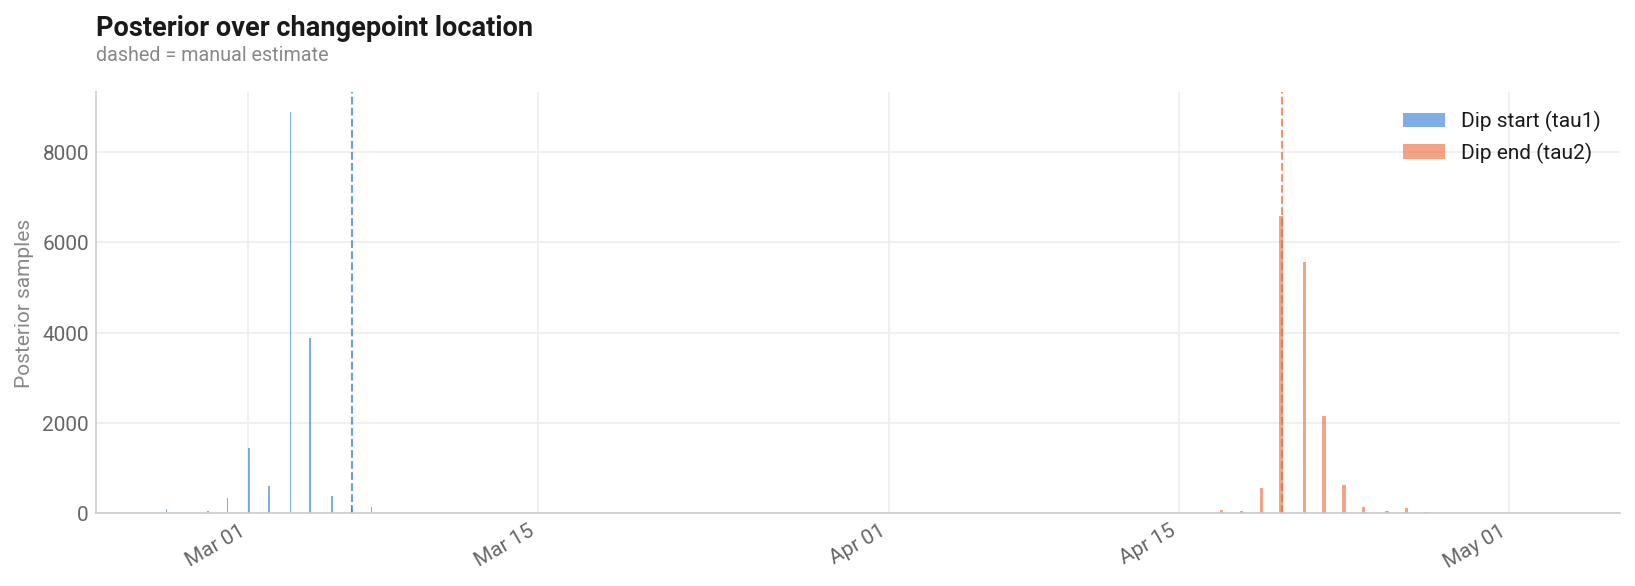

In [172]:
# Posterior over the changepoint dates themselves - worth looking at the
# actual shape, not just mean/hdi, since a bimodal posterior would average out
# to a "confident-looking" mean that no individual sample agrees with.
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(tau1_dates, bins=n, color=C_XG, alpha=0.6, label="Dip start (tau1)")
ax.hist(tau2_dates, bins=n, color=C_GOALS, alpha=0.6, label="Dip end (tau2)")
ax.axvline(pd.Timestamp("2026-03-06"), color=C_XG, linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(pd.Timestamp("2026-04-20"), color=C_GOALS, linestyle="--", linewidth=1, alpha=0.7)
ax.set_ylabel("Posterior samples", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(frameon=False, loc="upper right")
_dw_title(ax, "Posterior over changepoint location", "dashed = manual estimate", y=1.12, dy=0.055, size=13)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

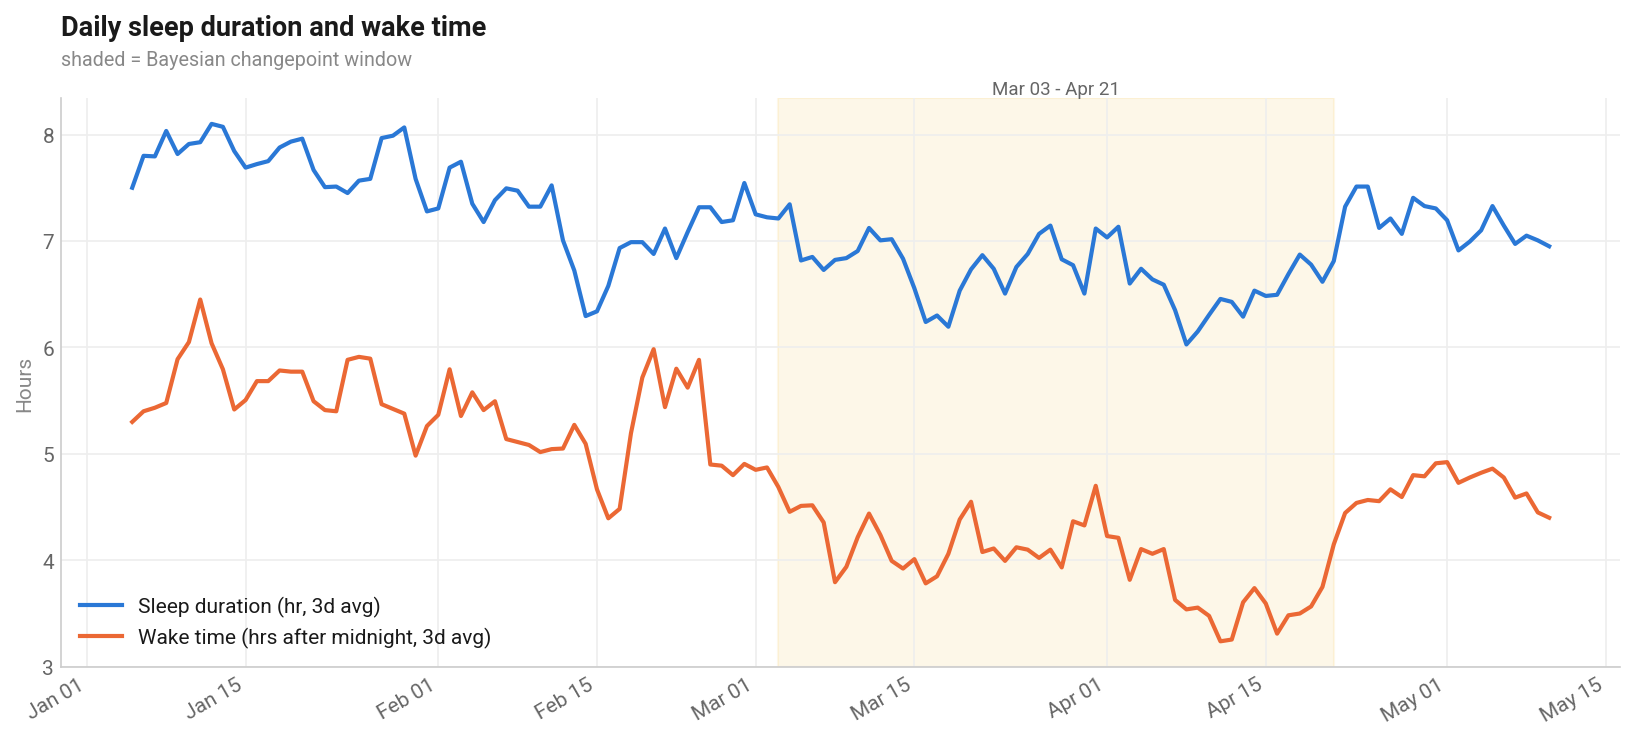

In [173]:
# Same duration/wake chart, now shaded with the changepoint MODEL's posterior
# median window (not the manual eyeball guess). Standalone panel - the form
# chart and the combined stacked version live in the next two cells.
dip_start = tau1_dates.median()
dip_end = tau2_dates.median()

fig, ax = plt.subplots(figsize=(11, 5))

ax.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax.plot(window["date"], window["duration_smooth"], color=C_XG, linewidth=2,
        label="Sleep duration (hr, 3d avg)")
ax.plot(window["date"], window["wake_smooth"], color=C_GOALS, linewidth=2,
        label="Wake time (hrs after midnight, 3d avg)")
mid = dip_start + (dip_end - dip_start) / 2
ax.text(mid, ax.get_ylim()[1], f"{dip_start:%b %d} - {dip_end:%b %d}", ha="center", va="bottom",
        color=C_INK2, fontsize=9)
ax.set_ylabel("Hours", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(frameon=False, loc="lower left")
_dw_title(ax, "Daily sleep duration and wake time", "shaded = Bayesian changepoint window",
          y=1.1, dy=0.05, size=13)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

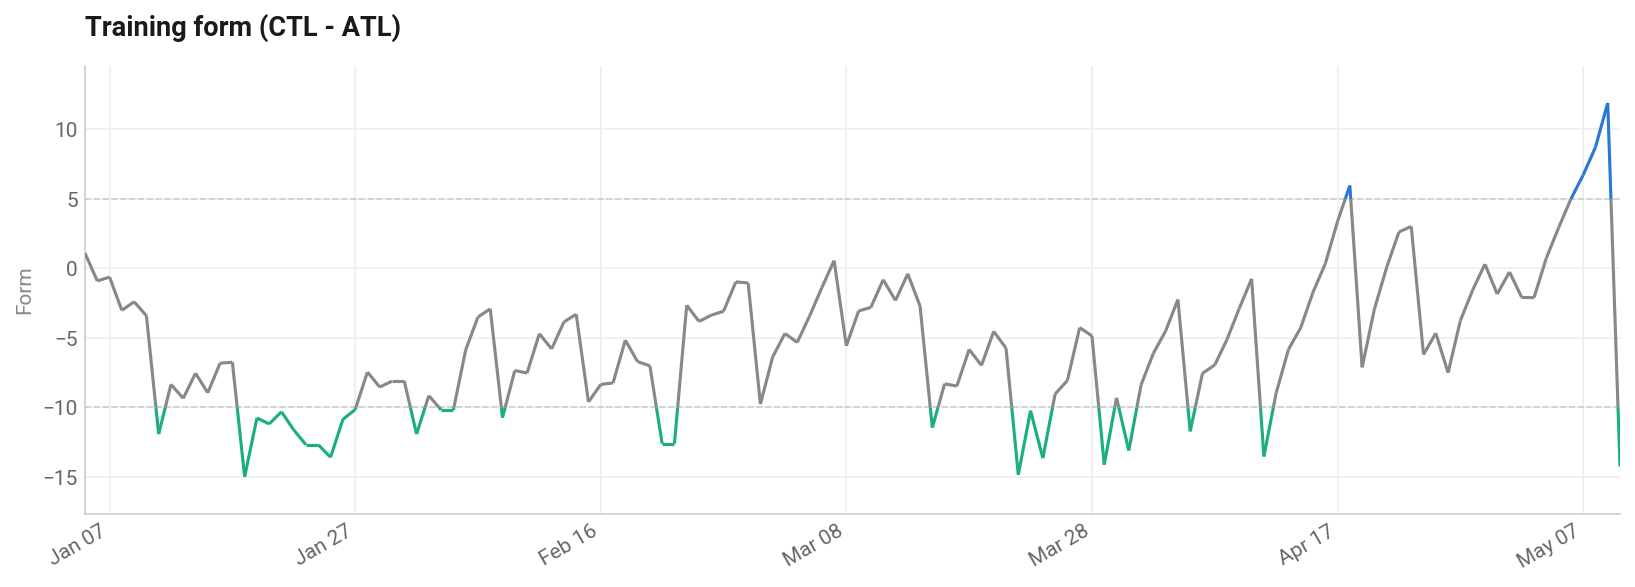

In [183]:
# Standalone form panel: form (CTL - ATL) over the same window, same
# changepoint shading. Three bands - green below -10 (fatigue), grey in the
# "normal" range, blue at 5 and above (fresh/well-recovered) - each segment
# that crosses a threshold is split at the true interpolated crossing point,
# so the color change happens exactly where the line crosses, not wherever a
# daily sample point happened to land.
from matplotlib.collections import LineCollection

form_window = merged.loc[merged["date"].between("2026-01-05", "2026-05-10"), ["date", "form"]].copy()
form_window = full_days.merge(form_window, on="date", how="left")

FATIGUE_THRESH = -10
FRESH_THRESH = 5
BAND_THRESHOLDS = [FATIGUE_THRESH, FRESH_THRESH]
BAND_COLORS = [C_PRED, C_MUTED, C_UNDER]  # below -10, -10 to 5, 5 and above


def _band_color(y, thresholds, colors):
    for t, c in zip(thresholds, colors[:-1]):
        if y < t:
            return c
    return colors[-1]


def banded_segments(x, y, thresholds, colors):
    segs, seg_colors = [], []
    for i in range(len(x) - 1):
        x0, y0, x1, y1 = x[i], y[i], x[i + 1], y[i + 1]
        crossings = []
        for t in thresholds:
            if (y0 - t) * (y1 - t) < 0:
                frac = (t - y0) / (y1 - y0)
                crossings.append((frac, t))
        crossings.sort()
        fracs = [0.0] + [c[0] for c in crossings] + [1.0]
        pts_y = [y0] + [c[1] for c in crossings] + [y1]
        pts_x = [x0 + f * (x1 - x0) for f in fracs]
        for j in range(len(pts_x) - 1):
            xa, ya, xb, yb = pts_x[j], pts_y[j], pts_x[j + 1], pts_y[j + 1]
            seg_color = _band_color((ya + yb) / 2, thresholds, colors)
            segs.append([[xa, ya], [xb, yb]])
            seg_colors.append(seg_color)
    return segs, seg_colors


fig, ax = plt.subplots(figsize=(11, 4))


x = mdates.date2num(form_window["date"])
y = form_window["form"].values
segs, seg_colors = banded_segments(x, y, BAND_THRESHOLDS, BAND_COLORS)
ax.add_collection(LineCollection(segs, colors=seg_colors, linewidth=1.5, zorder=3))
ax.set_xlim(x.min(), x.max())
pad = (y.max() - y.min()) * 0.1
ax.set_ylim(y.min() - pad, y.max() + pad)

ax.axhline(FATIGUE_THRESH, color=C_AXIS, linewidth=0.8, linestyle="--")
ax.axhline(FRESH_THRESH, color=C_AXIS, linewidth=0.8, linestyle="--")
ax.set_ylabel("Form", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
_dw_title(ax, "Training form (CTL - ATL)",
          y=1.05, dy=0.055, size=13)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

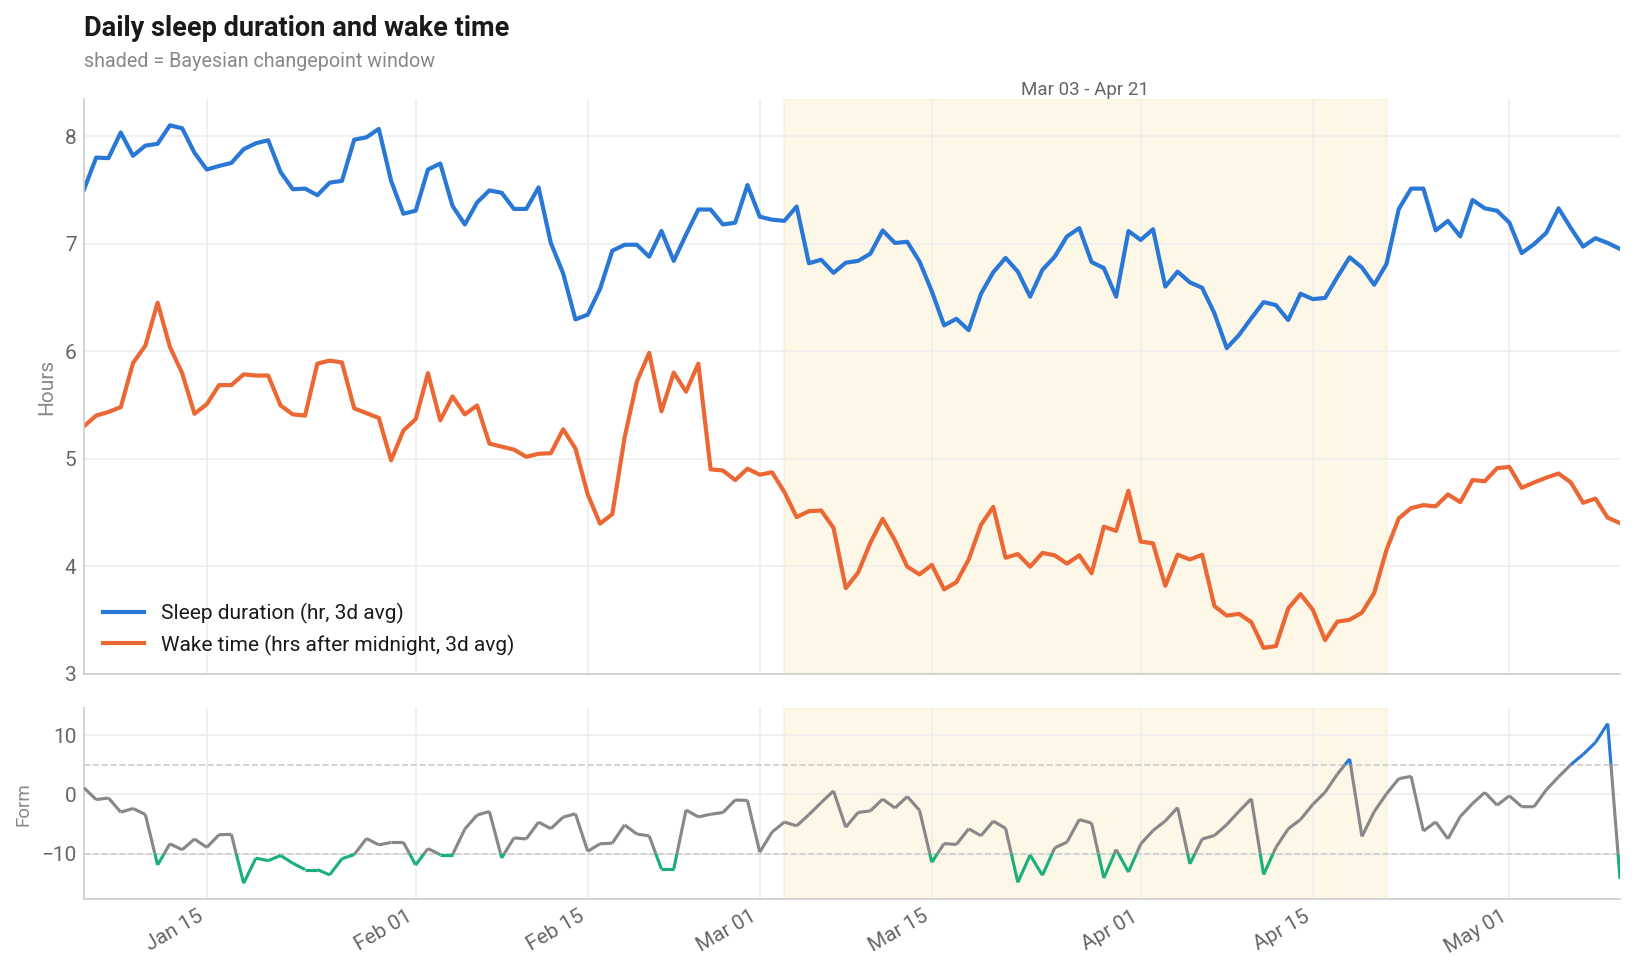

In [175]:
# Combined view: the two panels above stacked on a shared x-axis (rather than
# a twin y-axis, since form (CTL-ATL) and hours aren't the same unit) - useful
# for eyeballing whether the sleep changepoint and the form threshold-crossing
# line up in time.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax1.plot(window["date"], window["duration_smooth"], color=C_XG, linewidth=2,
         label="Sleep duration (hr, 3d avg)")
ax1.plot(window["date"], window["wake_smooth"], color=C_GOALS, linewidth=2,
         label="Wake time (hrs after midnight, 3d avg)")
mid = dip_start + (dip_end - dip_start) / 2
ax1.text(mid, ax1.get_ylim()[1], f"{dip_start:%b %d} - {dip_end:%b %d}", ha="center", va="bottom",
         color=C_INK2, fontsize=9)
ax1.set_ylabel("Hours", color=C_MUTED)
_dw_style(ax1, grid_axis="y")
ax1.legend(frameon=False, loc="lower left")
_dw_title(ax1, "Daily sleep duration and wake time", "shaded = Bayesian changepoint window",
          y=1.1, dy=0.05, size=13)

ax2.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
x = mdates.date2num(form_window["date"])
y = form_window["form"].values
segs, seg_colors = banded_segments(x, y, BAND_THRESHOLDS, BAND_COLORS)
ax2.add_collection(LineCollection(segs, colors=seg_colors, linewidth=1.5, zorder=3))
ax2.set_xlim(x.min(), x.max())
pad = (y.max() - y.min()) * 0.1
ax2.set_ylim(y.min() - pad, y.max() + pad)

ax2.axhline(FATIGUE_THRESH, color=C_AXIS, linewidth=0.8, linestyle="--")
ax2.axhline(FRESH_THRESH, color=C_AXIS, linewidth=0.8, linestyle="--")
ax2.set_ylabel("Form", color=C_MUTED, fontsize=9)
_dw_style(ax2, grid_axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [176]:
# Inventory every green streak (form < -10) in the window, not just eyeball
# the chart - tags each one as before/in/after the dip window, and measures
# both LENGTH (days) and DEPTH (cumulative "debt": sum of how far below -10
# it went, so one sharp 1-day spike to -18 doesn't count the same as a mild
# 6-day stretch sitting at -11). This is the direct test of "the dip-window
# green is different in kind from the explainable Jan spike," not just
# "there was some green in both."
gw = form_window.copy()
gw["green"] = gw["form"] < -10
gw["streak_id"] = (gw["green"] != gw["green"].shift()).cumsum()

streaks = (
    gw[gw["green"]]
    .groupby("streak_id")
    .agg(start=("date", "min"), end=("date", "max"), days=("date", "size"),
         min_form=("form", "min"),
         debt=("form", lambda s: (-10 - s).clip(lower=0).sum()))
    .reset_index(drop=True)
    .sort_values("start")
    .reset_index(drop=True)
)


def _period(row):
    if row["start"] >= dip_start and row["end"] <= dip_end:
        return "in dip window"
    if row["end"] < dip_start:
        return "before dip"
    if row["start"] > dip_end:
        return "after dip"
    return "straddles dip boundary"


streaks["period"] = streaks.apply(_period, axis=1)

print(streaks.assign(
    start=streaks["start"].dt.strftime("%b %d"),
    end=streaks["end"].dt.strftime("%b %d"),
    min_form=streaks["min_form"].round(1),
    debt=streaks["debt"].round(1),
).to_string(index=False))

print()
summary = streaks.groupby("period").agg(
    n_streaks=("days", "size"), total_days=("days", "sum"),
    total_debt=("debt", "sum"), mean_days=("days", "mean"), deepest=("min_form", "min"),
).round(1)
print(summary)

 start    end  days  min_form  debt        period
Jan 11 Jan 11     1     -11.9   1.9    before dip
Jan 18 Jan 27    10     -15.0  18.8    before dip
Feb 01 Feb 01     1     -11.9   1.9    before dip
Feb 03 Feb 04     2     -10.2   0.3    before dip
Feb 08 Feb 08     1     -10.7   0.7    before dip
Feb 21 Feb 22     2     -12.6   5.2    before dip
Mar 15 Mar 15     1     -11.5   1.5 in dip window
Mar 22 Mar 24     3     -14.8   8.7 in dip window
Mar 29 Mar 29     1     -14.1   4.1 in dip window
Mar 31 Mar 31     1     -13.1   3.1 in dip window
Apr 05 Apr 05     1     -11.7   1.7 in dip window
Apr 11 Apr 11     1     -13.5   3.5 in dip window
May 10 May 10     1     -14.3   4.3     after dip

               n_streaks  total_days  total_debt  mean_days  deepest
period                                                              
after dip              1           1         4.3        1.0    -14.3
before dip             6          17        28.9        2.8    -15.0
in dip window          

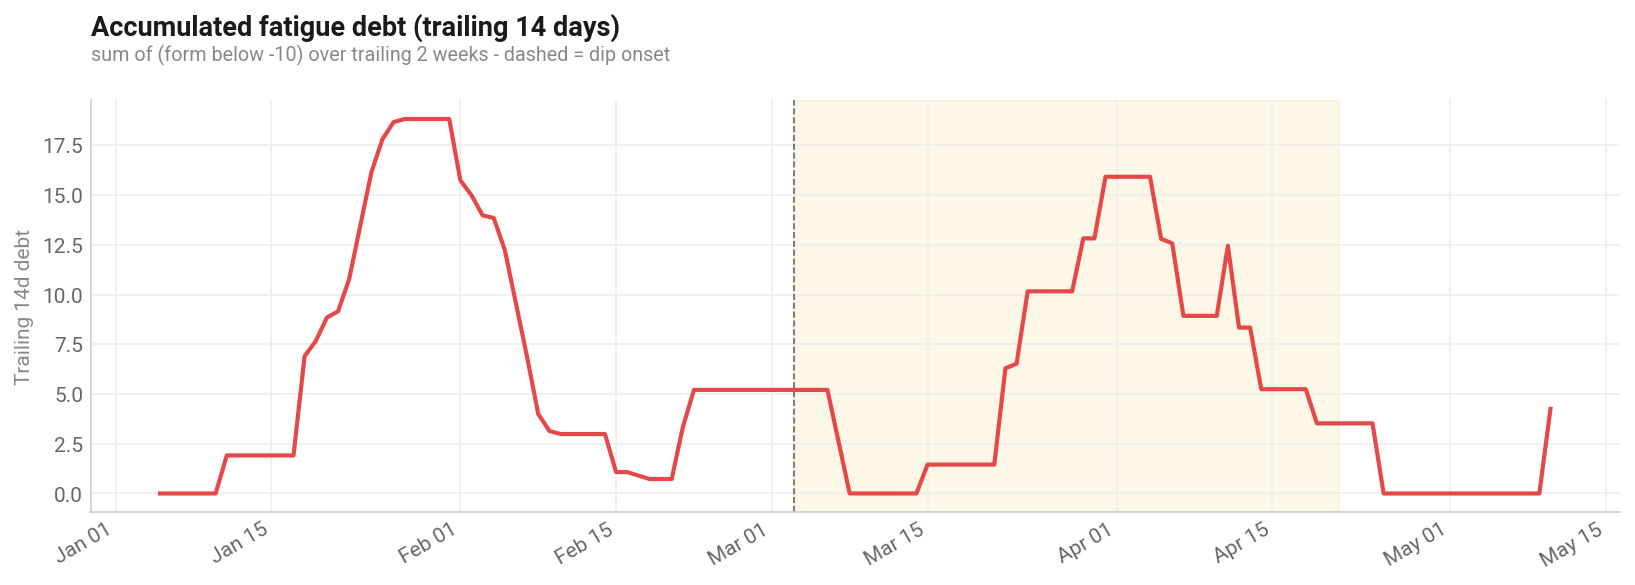

Trailing 14d debt at dip onset (Mar 03): 5.2
  -> 51th percentile of all days in the window
  (Jan spike sits right at the start of the tracked window, so its own trailing
   debt is mechanically near-zero from missing history - not a fair comparison;
   the percentile above is against the WHOLE window's distribution instead.)


In [177]:
# Trailing 14-day fatigue debt: rolling sum of how far below -10 form has
# been over the last two weeks. Tests whether fatigue was BUILDING UP going
# into Mar 3 (the modeled dip onset), rather than just being elevated once
# already inside the window - a real precursor should show a run-up before
# the dashed line, not just a plateau that starts exactly on it.
gw["daily_debt"] = (-10 - gw["form"]).clip(lower=0)
gw["trailing_debt_14d"] = gw["daily_debt"].rolling(14, min_periods=1).sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax.axvline(dip_start, color=C_INK2, linewidth=0.8, linestyle="--")
ax.plot(gw["date"], gw["trailing_debt_14d"], color=C_OVER, linewidth=2)
ax.set_ylabel("Trailing 14d debt", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
_dw_title(ax, "Accumulated fatigue debt (trailing 14 days)",
          "sum of (form below -10) over trailing 2 weeks - dashed = dip onset", y=1.14, dy=0.055, size=13)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

debt_at_onset = gw.loc[gw["date"] == dip_start, "trailing_debt_14d"].iloc[0]
pctile = (gw["trailing_debt_14d"] < debt_at_onset).mean() * 100
print(f"Trailing 14d debt at dip onset (Mar 03): {debt_at_onset:.1f}")
print(f"  -> {pctile:.0f}th percentile of all days in the window")
print(f"  (Jan spike sits right at the start of the tracked window, so its own trailing")
print(f"   debt is mechanically near-zero from missing history - not a fair comparison;")
print(f"   the percentile above is against the WHOLE window's distribution instead.)")

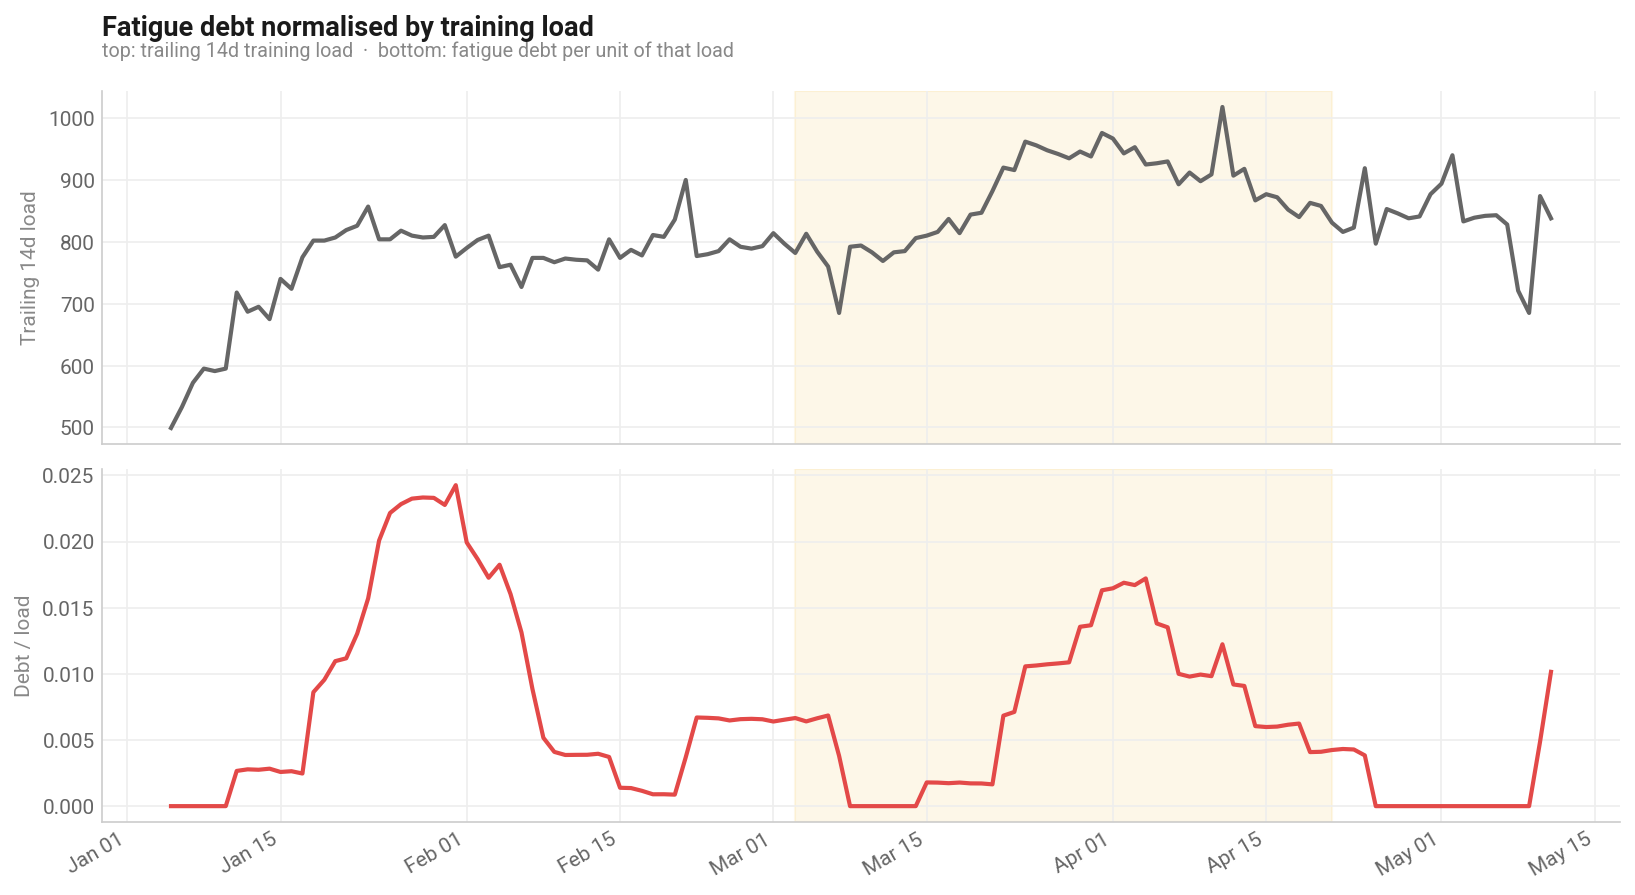

Jan 18-27 streak:  mean trailing load 815   mean debt/load 0.016
Dip window:        mean trailing load 872   mean debt/load 0.007


In [178]:
# Fatigue normalised by training load: raw "debt" conflates two different
# things - how much you trained, and how much your body reacted to it. The
# same debt earned from a huge training block is a healthy/expected response;
# the same debt earned from modest training is the more concerning signal
# (fatigue running ahead of what current load explains). Computed on `cal`
# (which has full history back to Dec 14) rather than the display window, so
# the trailing 14d sums for the first days of the window aren't truncated by
# missing pre-window history the way the debt-only chart's were.
cal["debt"] = (-10 - cal["form"]).clip(lower=0)
cal["debt_14d"] = cal["debt"].rolling(14, min_periods=1).sum()
cal["load_14d"] = cal["training_load"].rolling(14, min_periods=1).sum()
cal["debt_per_load"] = cal["debt_14d"] / cal["load_14d"].replace(0, np.nan)

fw = cal.loc[cal["date"].between("2026-01-05", "2026-05-11")].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                gridspec_kw={"height_ratios": [1, 1]})

ax1.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax1.plot(fw["date"], fw["load_14d"], color=C_INK2, linewidth=2)
ax1.set_ylabel("Trailing 14d load", color=C_MUTED)
_dw_style(ax1, grid_axis="y")
_dw_title(ax1, "Fatigue debt normalised by training load",
          "top: trailing 14d training load  ·  bottom: fatigue debt per unit of that load",
          y=1.14, dy=0.055, size=13)

ax2.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax2.plot(fw["date"], fw["debt_per_load"], color=C_OVER, linewidth=2)
ax2.set_ylabel("Debt / load", color=C_MUTED)
_dw_style(ax2, grid_axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

jan_streak = cal.loc[cal["date"].between("2026-01-18", "2026-01-27")]
dip_all = cal.loc[cal["date"].between(dip_start, dip_end)]
print(f"Jan 18-27 streak:  mean trailing load {jan_streak['load_14d'].mean():.0f}   "
      f"mean debt/load {jan_streak['debt_per_load'].mean():.3f}")
print(f"Dip window:        mean trailing load {dip_all['load_14d'].mean():.0f}   "
      f"mean debt/load {dip_all['debt_per_load'].mean():.3f}")

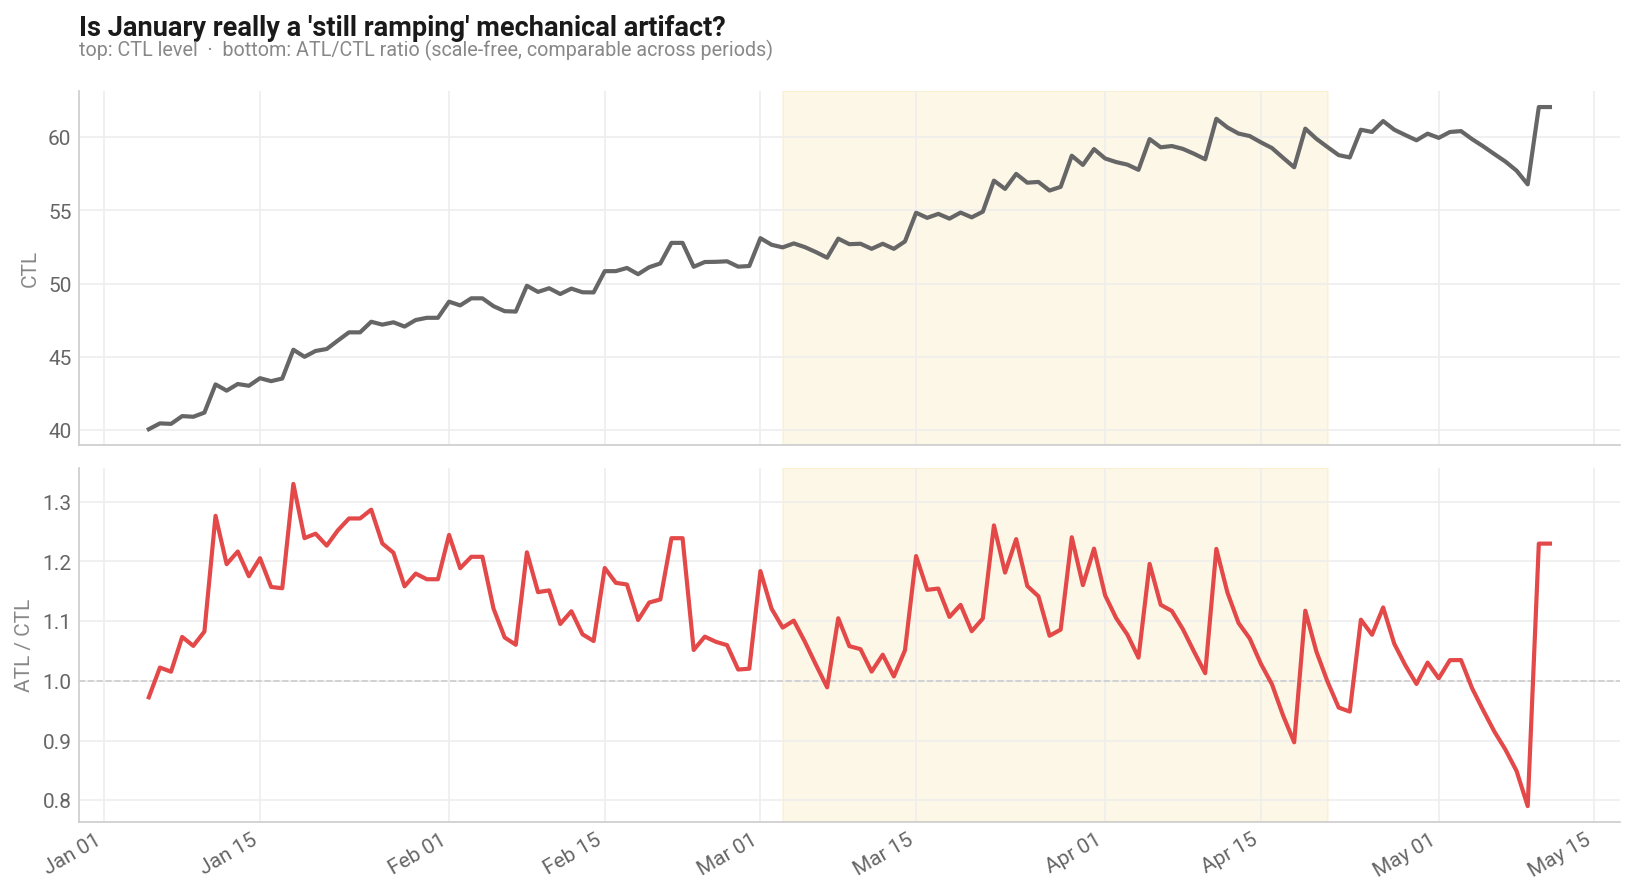

Jan 18-27 streak:  mean CTL 46.3   14d CTL growth +4.94/14d   ATL/CTL ratio 1.26
Dip window:        mean CTL 56.6   14d CTL growth +2.21/14d   ATL/CTL ratio 1.10


In [179]:
# Testing the "returning to training" mechanism directly, rather than just
# accepting it by reasoning: form = CTL - ATL, and CTL (~42-day time constant)
# responds far slower than ATL (~7-day). A sudden return to training after a
# break makes ATL jump quickly while CTL is still low and catching up, so TSB
# goes sharply negative almost by construction - independent of genuine
# overreaching. If that's what happened in January, CTL itself should still
# be visibly RAMPING (low level, fast growth) then, and comparatively settled
# (higher level, flat growth) by the dip window.
#
# The debt/load metric from the previous cell doesn't correct for this at all
# - it's still built on the raw CTL-ATL gap, which has exactly this
# base-level sensitivity. ATL/CTL as a RATIO (not a difference) is the
# standard sports-science fix (acute:chronic workload ratio) - it's scale-free,
# so a return-to-training period and an established-fitness period are
# actually comparable on it.
cal["ctl_14d_growth"] = cal["ctl"].diff(14)
cal["atl_ctl_ratio"] = cal["atl"] / cal["ctl"]

fw = cal.loc[cal["date"].between("2026-01-05", "2026-05-11")].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                gridspec_kw={"height_ratios": [1, 1]})

ax1.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax1.plot(fw["date"], fw["ctl"], color=C_INK2, linewidth=2, label="CTL (fitness)")
ax1.set_ylabel("CTL", color=C_MUTED)
_dw_style(ax1, grid_axis="y")
_dw_title(ax1, "Is January really a 'still ramping' mechanical artifact?",
          "top: CTL level  ·  bottom: ATL/CTL ratio (scale-free, comparable across periods)",
          y=1.14, dy=0.055, size=13)

ax2.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax2.axhline(1.0, color=C_AXIS, linewidth=0.8, linestyle="--")
ax2.plot(fw["date"], fw["atl_ctl_ratio"], color=C_OVER, linewidth=2)
ax2.set_ylabel("ATL / CTL", color=C_MUTED)
_dw_style(ax2, grid_axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

jan_streak = cal.loc[cal["date"].between("2026-01-18", "2026-01-27")]
dip_all = cal.loc[cal["date"].between(dip_start, dip_end)]
print(f"Jan 18-27 streak:  mean CTL {jan_streak['ctl'].mean():.1f}   "
      f"14d CTL growth {jan_streak['ctl_14d_growth'].mean():+.2f}/14d   "
      f"ATL/CTL ratio {jan_streak['atl_ctl_ratio'].mean():.2f}")
print(f"Dip window:        mean CTL {dip_all['ctl'].mean():.1f}   "
      f"14d CTL growth {dip_all['ctl_14d_growth'].mean():+.2f}/14d   "
      f"ATL/CTL ratio {dip_all['atl_ctl_ratio'].mean():.2f}")

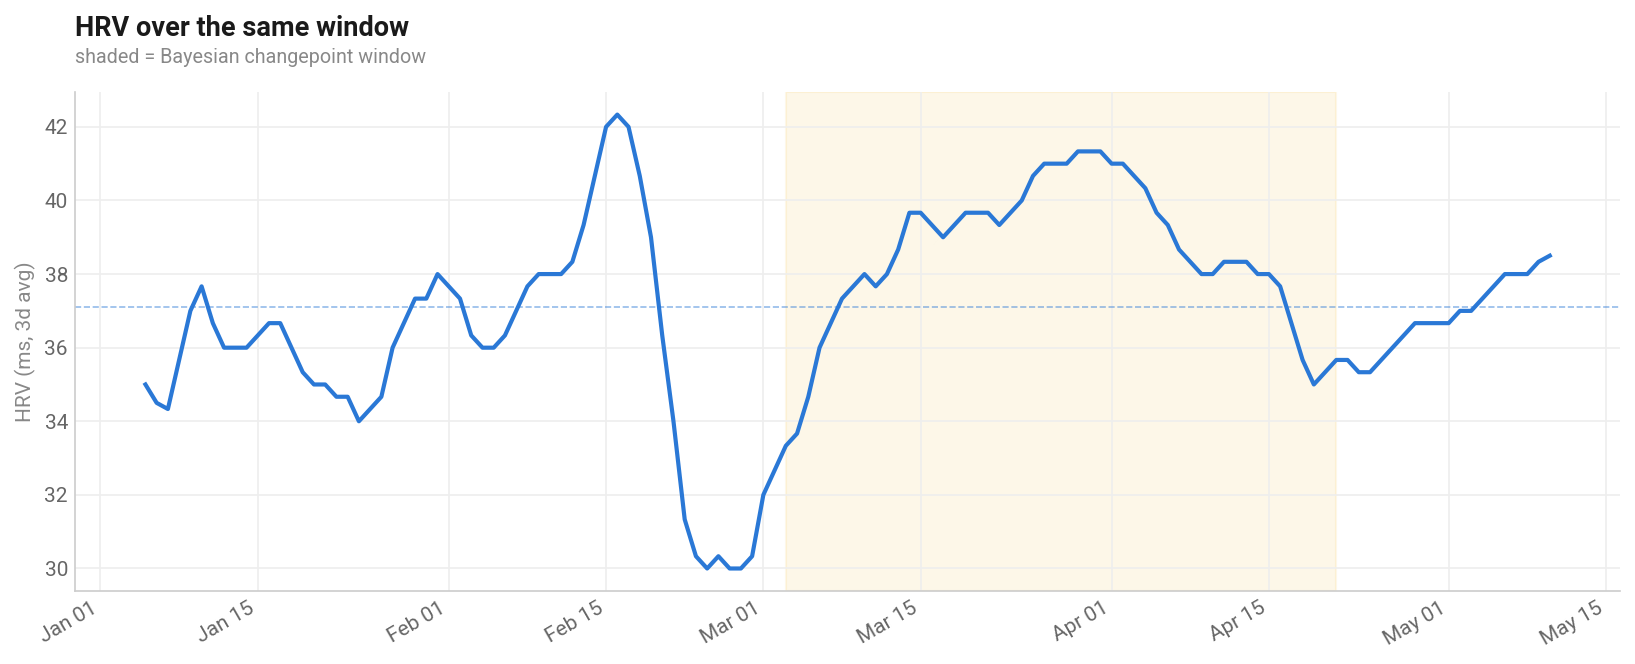

Jan 18-27 streak:  mean HRV 35.0
Before dip:        mean HRV 35.9
Dip window:        mean HRV 38.6
After dip:         mean HRV 36.8


In [180]:
# HRV is a more direct physiological stress/recovery signal than training
# load or form - if the dip window represents genuine accumulated strain
# (not caught by the training-side metrics above), it should show up as
# LOWER HRV during that window, since HRV drops under sympathetic/stress
# load. Full coverage: 126/126 nights have an HRV Status reading.
hrv_window = sleep_clean.loc[sleep_clean["date"].between("2026-01-05", "2026-05-11"), ["date", "HRV Status"]].copy()
hrv_window = full_days.merge(hrv_window, on="date", how="left")
hrv_window["hrv_smooth"] = hrv_window["HRV Status"].rolling(3, min_periods=1).mean()
hrv_mean = hrv_window["hrv_smooth"].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax.axhline(hrv_mean, color=C_XG, linewidth=0.8, linestyle="--", alpha=0.5)
ax.plot(hrv_window["date"], hrv_window["hrv_smooth"], color=C_XG, linewidth=2)
ax.set_ylabel("HRV (ms, 3d avg)", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
_dw_title(ax, "HRV over the same window", "shaded = Bayesian changepoint window", y=1.1, dy=0.05, size=13)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

sc_hrv = sleep_clean.loc[sleep_clean["date"].between("2026-01-05", "2026-05-11"), ["date", "HRV Status"]]
jan_streak = sc_hrv[sc_hrv["date"].between("2026-01-18", "2026-01-27")]
dip_all = sc_hrv[sc_hrv["date"].between(dip_start, dip_end)]
before = sc_hrv[sc_hrv["date"] < dip_start]
after = sc_hrv[sc_hrv["date"] > dip_end]
print(f"Jan 18-27 streak:  mean HRV {jan_streak['HRV Status'].mean():.1f}")
print(f"Before dip:        mean HRV {before['HRV Status'].mean():.1f}")
print(f"Dip window:        mean HRV {dip_all['HRV Status'].mean():.1f}")
print(f"After dip:         mean HRV {after['HRV Status'].mean():.1f}")

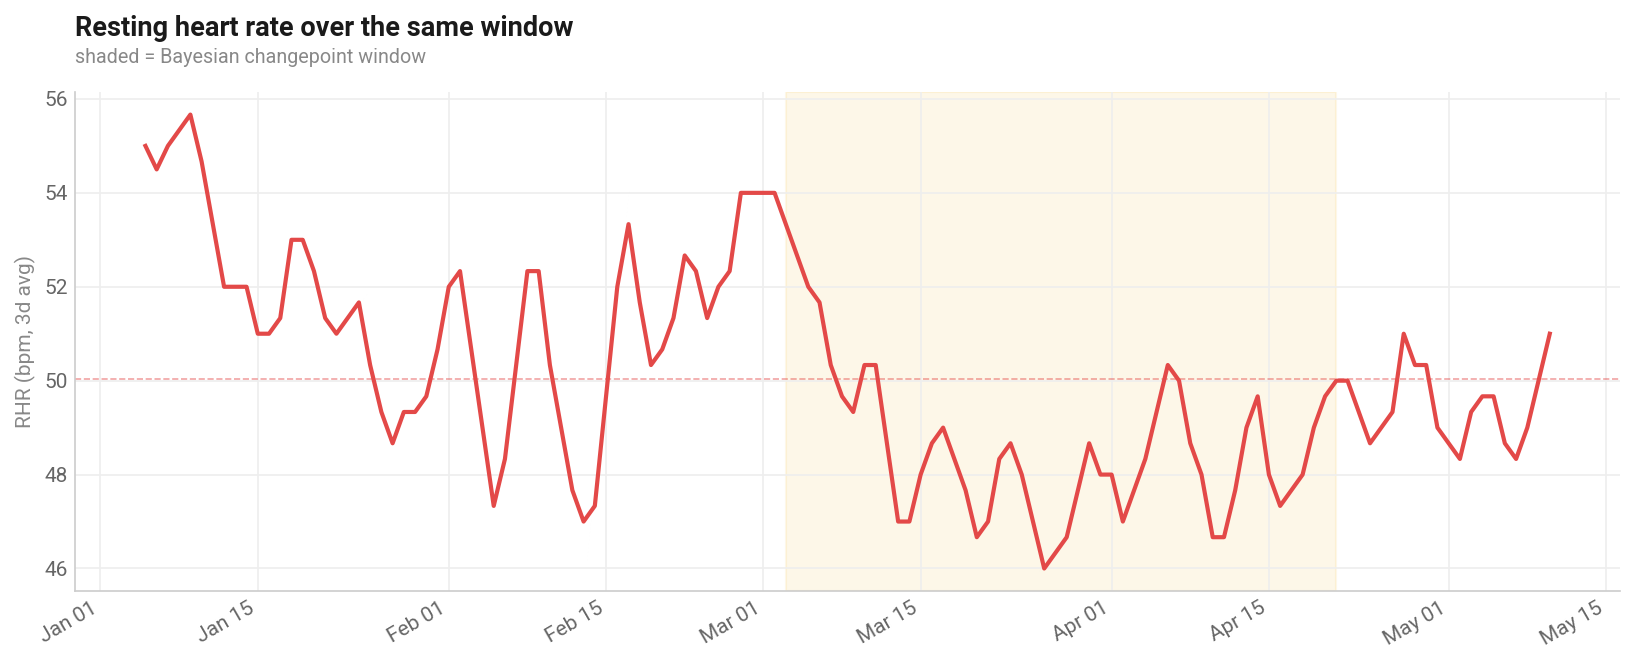

Jan 18-27 streak:  mean RHR 50.8
Before dip:        mean RHR 51.5
Dip window:        mean RHR 48.5
After dip:         mean RHR 49.7


In [181]:
# Resting heart rate: the other classic overreaching marker, distinct from
# HRV (autonomic tone) and from ATL/CTL (training-load bookkeeping) - chronic
# overreaching/HPA-axis strain should show up as ELEVATED RHR, not lower.
rhr_window = sleep_clean.loc[sleep_clean["date"].between("2026-01-05", "2026-05-11"), ["date", "Resting Heart Rate"]].copy()
rhr_window = full_days.merge(rhr_window, on="date", how="left")
rhr_window["rhr_smooth"] = rhr_window["Resting Heart Rate"].rolling(3, min_periods=1).mean()
rhr_mean = rhr_window["rhr_smooth"].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax.axhline(rhr_mean, color=C_OVER, linewidth=0.8, linestyle="--", alpha=0.5)
ax.plot(rhr_window["date"], rhr_window["rhr_smooth"], color=C_OVER, linewidth=2)
ax.set_ylabel("RHR (bpm, 3d avg)", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
_dw_title(ax, "Resting heart rate over the same window", "shaded = Bayesian changepoint window",
          y=1.1, dy=0.05, size=13)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

sc_rhr = sleep_clean.loc[sleep_clean["date"].between("2026-01-05", "2026-05-11"), ["date", "Resting Heart Rate"]]
jan_streak = sc_rhr[sc_rhr["date"].between("2026-01-18", "2026-01-27")]
dip_all = sc_rhr[sc_rhr["date"].between(dip_start, dip_end)]
before = sc_rhr[sc_rhr["date"] < dip_start]
after = sc_rhr[sc_rhr["date"] > dip_end]
print(f"Jan 18-27 streak:  mean RHR {jan_streak['Resting Heart Rate'].mean():.1f}")
print(f"Before dip:        mean RHR {before['Resting Heart Rate'].mean():.1f}")
print(f"Dip window:        mean RHR {dip_all['Resting Heart Rate'].mean():.1f}")
print(f"After dip:         mean RHR {after['Resting Heart Rate'].mean():.1f}")

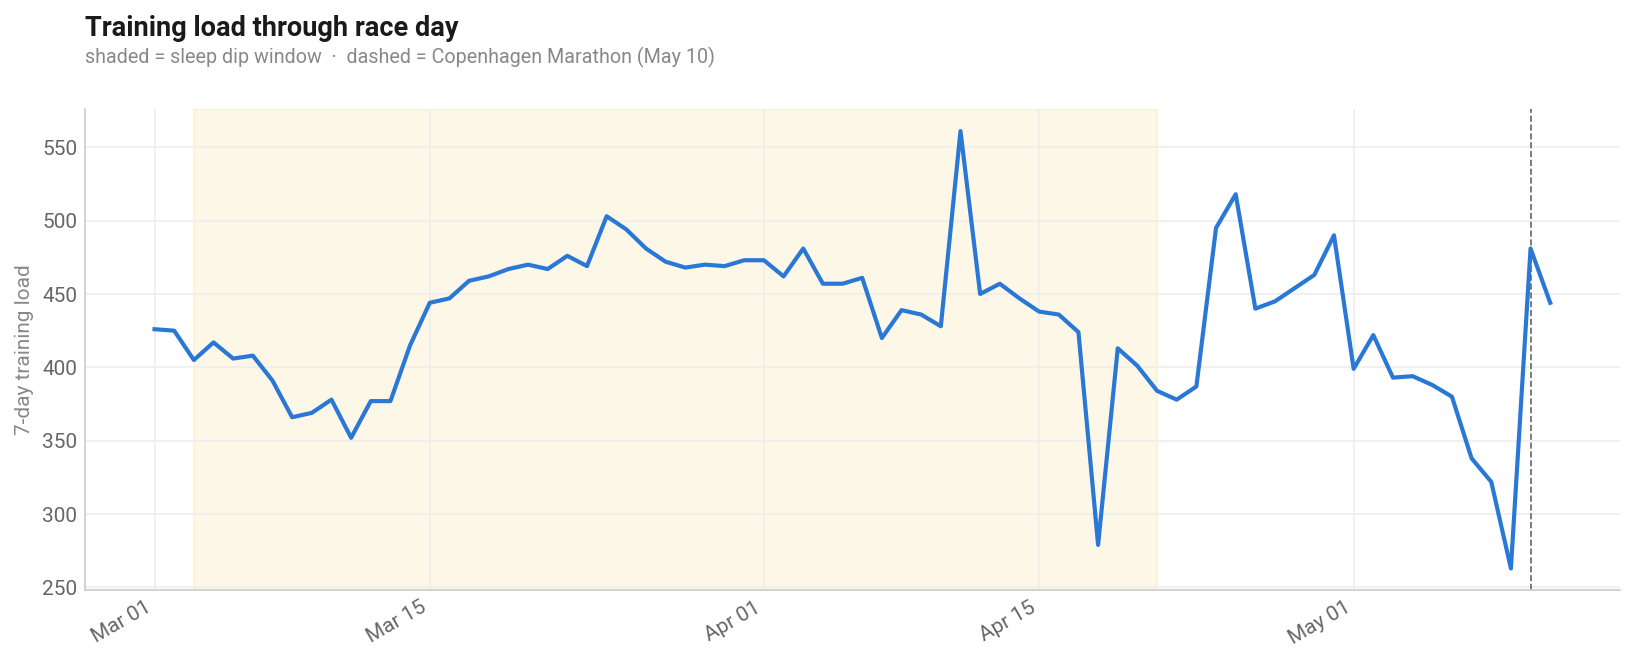

Sleep dip window (model):     Mar 03 - Apr 21
Training block plateau level: 452 (mean 7d load, Mar 15 - Apr 30)
Taper start (load permanently drops >15% below plateau): May 06
Race day: May 10

Gap between sleep recovery (tau2, Apr 21) and taper actually starting (May 06): 15 days
Training stayed at plateau level for 15 days AFTER sleep had already recovered.


In [182]:
# Direct test of "sleep recovered because I tapered": Copenhagen Marathon was
# May 10 (the 42.76km "CPH Marathon" activity - hence the window ending May
# 11). If the taper genuinely explains the recovery, its start should closely
# PRECEDE tau2 (the model's recovery date). Extending the display through
# race day to see the real shape of the taper, not just the display window.
taper_view = cal.loc[cal["date"].between("2026-03-01", "2026-05-11")].copy()
race_day = pd.Timestamp("2026-05-10")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(dip_start, dip_end, color="#f5c542", alpha=0.12, zorder=0)
ax.axvline(race_day, color=C_INK2, linewidth=0.8, linestyle="--")
ax.plot(taper_view["date"], taper_view["load_7d"], color=C_XG, linewidth=2)
ax.set_ylabel("7-day training load", color=C_MUTED)
_dw_style(ax, grid_axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
_dw_title(ax, "Training load through race day", "shaded = sleep dip window  ·  dashed = Copenhagen Marathon (May 10)",
          y=1.14, dy=0.055, size=13)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Taper start, done properly: a single big long-run day inflates the 7-day
# rolling sum for a week afterward, so "first day >15% below the single
# highest day" (the naive version) just grabs noise around one long run, not
# a real taper. Instead: for each day, take the MAX load_7d over every
# remaining day through race eve (a forward-looking max) - the taper start is
# the first day that forward-looking max drops below and STAYS below a
# threshold off the block's plateau level, i.e. the load never spikes back up
# again before race day.
pre_race = cal.loc[cal["date"].between("2026-03-01", "2026-05-09")].reset_index(drop=True)
pre_race["fwd_max"] = pre_race["load_7d"][::-1].cummax()[::-1]
block_level = cal.loc[cal["date"].between("2026-03-15", "2026-04-30"), "load_7d"].mean()
taper_start = pre_race.loc[pre_race["fwd_max"] < block_level * 0.85, "date"].min()

print(f"Sleep dip window (model):     {dip_start:%b %d} - {dip_end:%b %d}")
print(f"Training block plateau level: {block_level:.0f} (mean 7d load, Mar 15 - Apr 30)")
print(f"Taper start (load permanently drops >15% below plateau): {taper_start:%b %d}")
print(f"Race day: {race_day:%b %d}")
print(f"\nGap between sleep recovery (tau2, {dip_end:%b %d}) and taper actually starting "
      f"({taper_start:%b %d}): {(taper_start - dip_end).days} days")
print(f"Training stayed at plateau level for {(taper_start - dip_end).days} days AFTER sleep had already recovered.")